In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download('stopwords', quiet=True)

True

**LOAD DATASET**

In [41]:
# Load the Amazon Fine Food Reviews subset
df = pd.read_csv(r'C:\Users\tladi\Downloads\archive (3)\amazon_fine_food_reviews_10000.csv')  # adjust path as needed

print("Initial shape:", df.shape)
df.head()

Initial shape: (5000, 6)


,Id,ProductId,UserId,ProfileName,Score,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,5,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,1,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",4,This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,2,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",5,Great taffy at a great price. There was a wid...


**HANDLE MISSING VALUES**

In [3]:
# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Id             0
ProductId      0
UserId         0
ProfileName    0
Score          0
Text           0
dtype: int64


**REMOVE DUPLICATES**

In [42]:
# Remove exact duplicate reviews (same Text)
df.drop_duplicates(subset='Text', inplace=True)

# remove reviews with identical Text but different UserId/ProductId
# (keeps the first occurrence)
df.drop_duplicates(subset=['Text', 'UserId', 'ProductId'], inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4984, 6)


**TEXT PREPROCESSING**

In [5]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Apply lowercasing, punctuation removal, and stopword removal.
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and numbers (keep only letters and whitespace)
    text = re.sub(f'[{re.escape(string.punctuation)}0-9]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and remove stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    
    return ' '.join(filtered_words)

# Apply preprocessing and create a new column
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

print("\nSample original and cleaned text:")
for i in range(3):
    print("---")
    print("Original:", df.iloc[i]['Text'][:200], "...")
    print("Cleaned:", df.iloc[i]['Cleaned_Text'][:200], "...")


Sample original and cleaned text:
---
Original: I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador ...
Cleaned: bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better ...
---
Original: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo". ...
Cleaned: product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent product jumbo ...
---
Original: This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with po

**QUICK SENTIMENT LABEL (for later use)**

In [7]:
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else (0 if x <= 2 else None))
print("\nSentiment distribution:")
print(df['Sentiment'].value_counts())


Sentiment distribution:
Sentiment
1.0    3837
0.0     754
Name: count, dtype: int64


**SAVE CLEANED DATASET**

In [8]:
df.to_csv('cleaned_reviews.csv', index=False)
print("\nCleaned data saved to 'cleaned_reviews.csv'")


Cleaned data saved to 'cleaned_reviews.csv'


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**LOAD CLEANED DATA (from previous step)**

In [10]:
df = pd.read_csv('cleaned_reviews.csv')
df = df.dropna(subset=['Cleaned_Text', 'Sentiment'])   # keep only rows with a sentiment label

**FEATURE SELECTION**

In [11]:
# TF-IDF with unigrams and bigrams; remove very rare/very common terms
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,          # hyperparameter: max_features
    ngram_range=(1, 2),         # includes both 1‑grams and 2‑grams
    stop_words='english',       # redundant but safe
    max_df=0.8,                 # ignore terms appearing in >80% of docs
    min_df=5                    # ignore terms appearing in <5 docs
)

X = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])
y = df['Sentiment'].astype(int)

print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (4591, 5000)


**TRAIN-TEST SPLIT**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 3672, Test size: 919


**MODEL TRAINING with HYPERPARAMETERS**

In [13]:
# Logistic Regression with class balancing
model = LogisticRegression(
    max_iter=500,               # epochs equivalent for convergence
    class_weight='balanced',    # handle class imbalance
    C=0.8,                      # inverse regularization strength (tuneable)
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.8
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


**EVALUATION**

In [15]:
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Overall Accuracy:", round(accuracy_score(y_test, y_pred), 3))


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.74      0.63       151
           1       0.95      0.88      0.91       768

    accuracy                           0.86       919
   macro avg       0.75      0.81      0.77       919
weighted avg       0.88      0.86      0.86       919

Overall Accuracy: 0.856


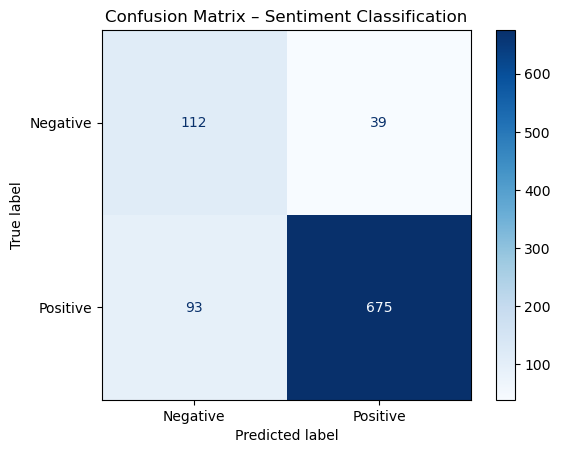

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Sentiment Classification")
plt.show()

In [29]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.naive_bayes import MultinomialNB

In [20]:
df = pd.read_csv('cleaned_reviews.csv')
print("Initial shape:", df.shape)

Initial shape: (4984, 8)


In [21]:
# Drop duplicate reviews (same Text)
df.drop_duplicates(subset='Text', inplace=True)
# Remove rows with missing Text or Score
df.dropna(subset=['Text', 'Score'], inplace=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (4984, 8)


In [22]:
stop_words = set(stopwords.words('english'))

def normalize_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and digits (keep letters and spaces)
    text = re.sub(f'[{re.escape(string.punctuation)}0-9]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

# Apply normalisation
df['Clean_Text'] = df['Text'].apply(normalize_text)
print("Normalisation complete.")

Normalisation complete.


Median review length: 27.0 words
Mean review length: 38.2 words
Max review length: 516 words


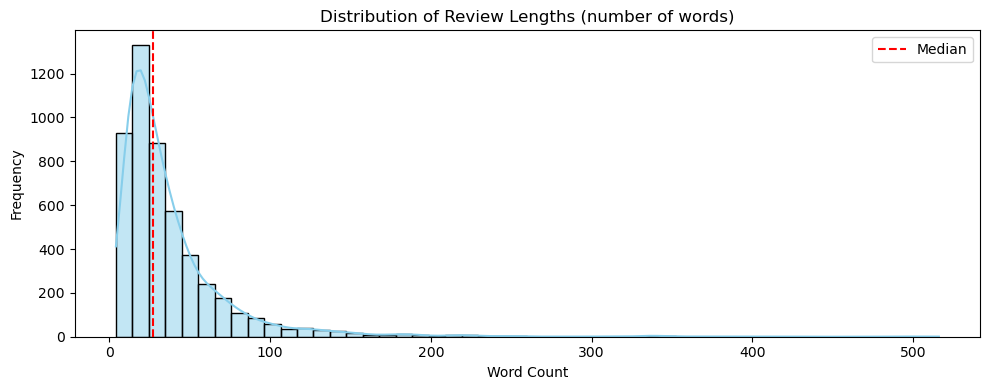

In [26]:
# Count words in each cleaned review
df['Review_Length'] = df['Clean_Text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,4))
sns.histplot(df['Review_Length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths (number of words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(df['Review_Length'].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('review_length_distribution.png')
plt.show

# Print basic stats
print(f"Median review length: {df['Review_Length'].median():.1f} words")
print(f"Mean review length: {df['Review_Length'].mean():.1f} words")
print(f"Max review length: {df['Review_Length'].max()} words")

C:\Users\tladi\AppData\Local\Temp\ipykernel_2984\1133421043.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='Frequency', y='Word', palette='viridis')


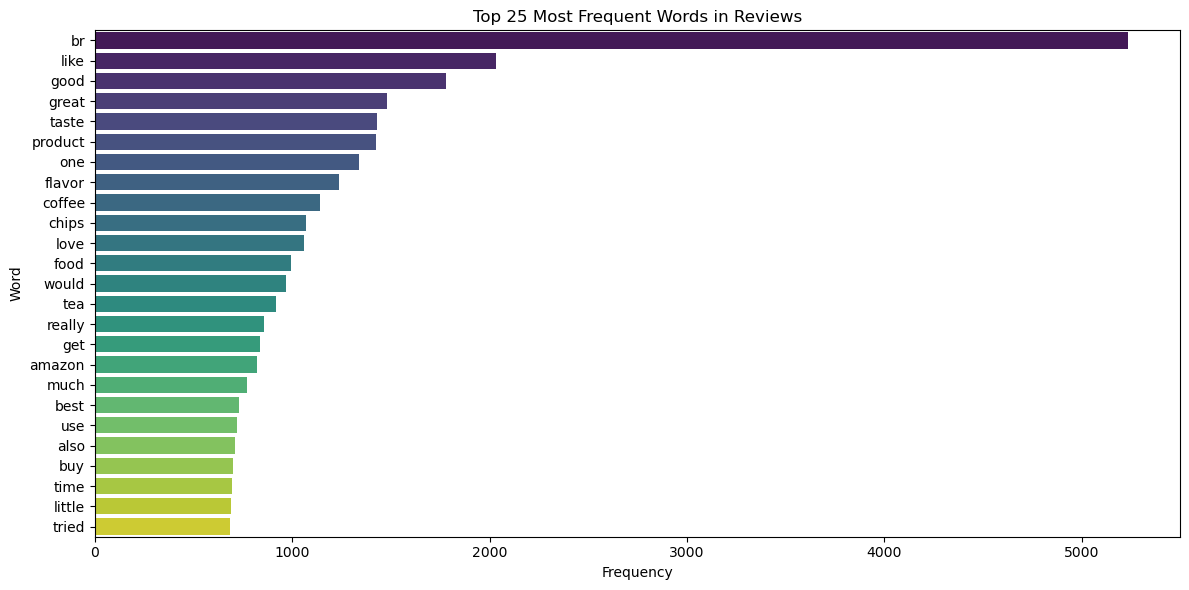

In [27]:
# Concatenate all cleaned reviews
all_words = ' '.join(df['Clean_Text']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(25)

# Create DataFrame for plotting
top_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12,6))
sns.barplot(data=top_df, x='Frequency', y='Word', palette='viridis')
plt.title('Top 25 Most Frequent Words in Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('top_words_barplot.png')
plt.show()

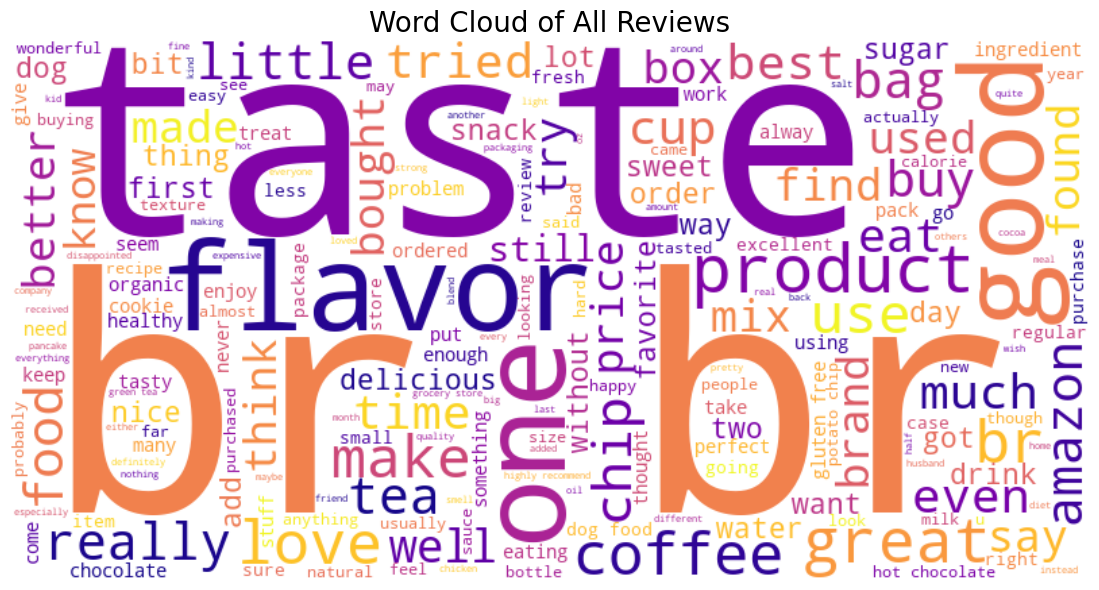

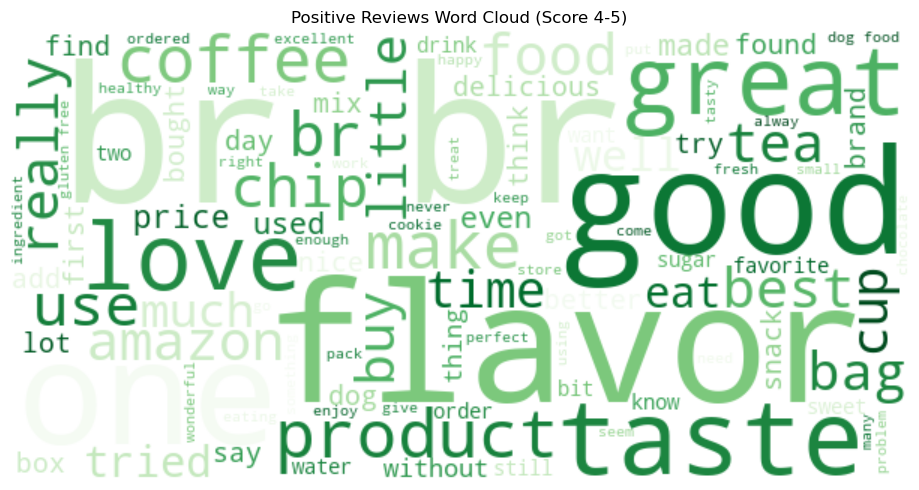

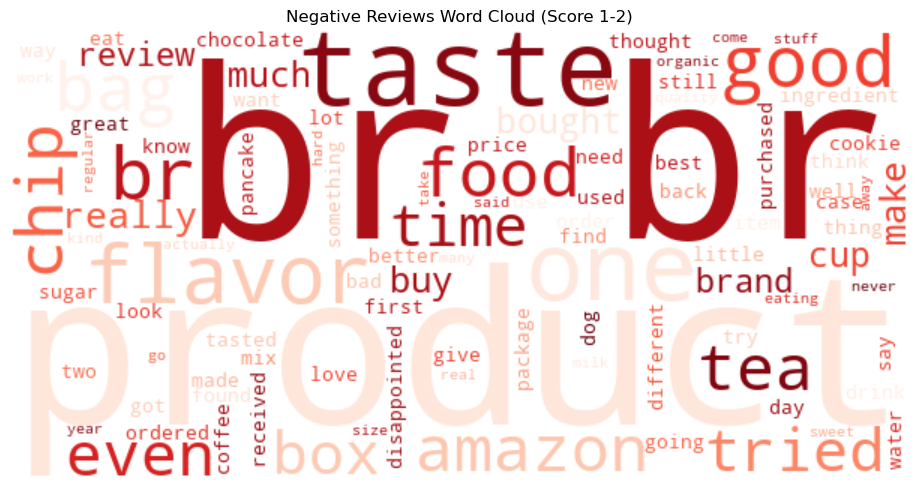

EDA visualisations saved: review_length_distribution.png, top_words_barplot.png, wordclouds


In [28]:
# Generate word cloud from all reviews
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      max_words=200, colormap='plasma').generate(' '.join(df['Clean_Text']))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Reviews', fontsize=20)
plt.tight_layout()
plt.savefig('wordcloud_all_reviews.png')
plt.show()

# Optional: Word clouds by sentiment (positive vs negative)
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else (0 if x <= 2 else None))
positive_text = ' '.join(df[df['Sentiment'] == 1]['Clean_Text'].dropna())
negative_text = ' '.join(df[df['Sentiment'] == 0]['Clean_Text'].dropna())

# Positive word cloud
pos_wc = WordCloud(width=600, height=300, background_color='white', 
                   colormap='Greens', max_words=100).generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud (Score 4-5)')
plt.tight_layout()
plt.savefig('wordcloud_positive.png')
plt.show()

# Negative word cloud
neg_wc = WordCloud(width=600, height=300, background_color='white', 
                   colormap='Reds', max_words=100).generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud (Score 1-2)')
plt.tight_layout()
plt.savefig('wordcloud_negative.png')
plt.show()

print("EDA visualisations saved: review_length_distribution.png, top_words_barplot.png, wordclouds")

In [31]:
# TRAIN-TEST SPLIT (80/20, stratified)
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 3672, Test size: 919


In [32]:
# MODEL 1: LOGISTIC REGRESSION
# =============================================
lr = LogisticRegression(
    max_iter=500,            # allow enough iterations for convergence
    C=0.8,                   # inverse regularisation strength (smaller = stronger)
    class_weight='balanced', # adjust weights inversely proportional to class frequencies
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")


=== Logistic Regression Performance ===
              precision    recall  f1-score   support

    Negative       0.55      0.74      0.63       151
    Positive       0.95      0.88      0.91       768

    accuracy                           0.86       919
   macro avg       0.75      0.81      0.77       919
weighted avg       0.88      0.86      0.86       919

Accuracy: 0.856


In [33]:
# MODEL 2: MULTINOMIAL NAÏVE BAYES
# =============================================
mnb = MultinomialNB(alpha=0.1)    # smoothing parameter
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

print("\n=== Multinomial Naïve Bayes Performance ===")
print(classification_report(y_test, y_pred_mnb, target_names=['Negative','Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_mnb):.3f}")


=== Multinomial Naïve Bayes Performance ===
              precision    recall  f1-score   support

    Negative       0.89      0.36      0.52       151
    Positive       0.89      0.99      0.94       768

    accuracy                           0.89       919
   macro avg       0.89      0.68      0.73       919
weighted avg       0.89      0.89      0.87       919

Accuracy: 0.888


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# =============================================
# 1. RELOAD DATA & VECTORISE (same as before)
# =============================================
df = pd.read_csv('cleaned_reviews.csv')
df = df.dropna(subset=['Cleaned_Text', 'Sentiment'])   # FIXED column name

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    max_df=0.8,
    min_df=5
)
X = tfidf.fit_transform(df['Cleaned_Text'])   # FIXED column name
y = df['Sentiment'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
# 2. HYPERPARAMETER TUNING – LOGISTIC REGRESSION
# =============================================
param_grid_lr = {
    'C': [0.1, 0.5, 0.8, 1.0, 5.0],
    'class_weight': ['balanced', None],
    'max_iter': [300, 500]
}
lr_base = LogisticRegression(random_state=42)
grid_lr = GridSearchCV(lr_base, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV (macro F1):", grid_lr.best_score_.round(3))

y_pred_lr_tuned = grid_lr.predict(X_test)
print("\n=== Tuned Logistic Regression ===")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Negative','Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LR params: {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 300}
Best LR CV (macro F1): 0.801

=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.56      0.74      0.64       151
    Positive       0.95      0.89      0.91       768

    accuracy                           0.86       919
   macro avg       0.75      0.81      0.78       919
weighted avg       0.88      0.86      0.87       919

Accuracy: 0.862


In [40]:
# 3. ALTERNATIVE MODEL: LinearSVC
# =============================================
param_grid_svc = {
    'C': [0.1, 0.5, 1.0],
    'class_weight': ['balanced', None],
    'max_iter': [1000, 2000]
}
svc = LinearSVC(random_state=42, dual=False)   # dual=False for large feature sets
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svc.fit(X_train, y_train)

print("Best SVC params:", grid_svc.best_params_)
print("Best SVC CV (macro F1):", grid_svc.best_score_.round(3))

y_pred_svc = grid_svc.predict(X_test)
print("\n=== Tuned Linear SVC ===")
print(classification_report(y_test, y_pred_svc, target_names=['Negative','Positive']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVC params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000}
Best SVC CV (macro F1): 0.799

=== Tuned Linear SVC ===
              precision    recall  f1-score   support

    Negative       0.56      0.74      0.63       151
    Positive       0.94      0.88      0.91       768

    accuracy                           0.86       919
   macro avg       0.75      0.81      0.77       919
weighted avg       0.88      0.86      0.87       919

Accuracy: 0.860
